**Load and prepare**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Load
rfm = pd.read_csv("../output/rfm_segments.csv")
rfm["Churn"] = rfm["Segment"].apply(lambda x: 1 if x in ["At Risk", "Lost"] else 0)

X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 3470 | Test: 868


**Train and visualise the tree**

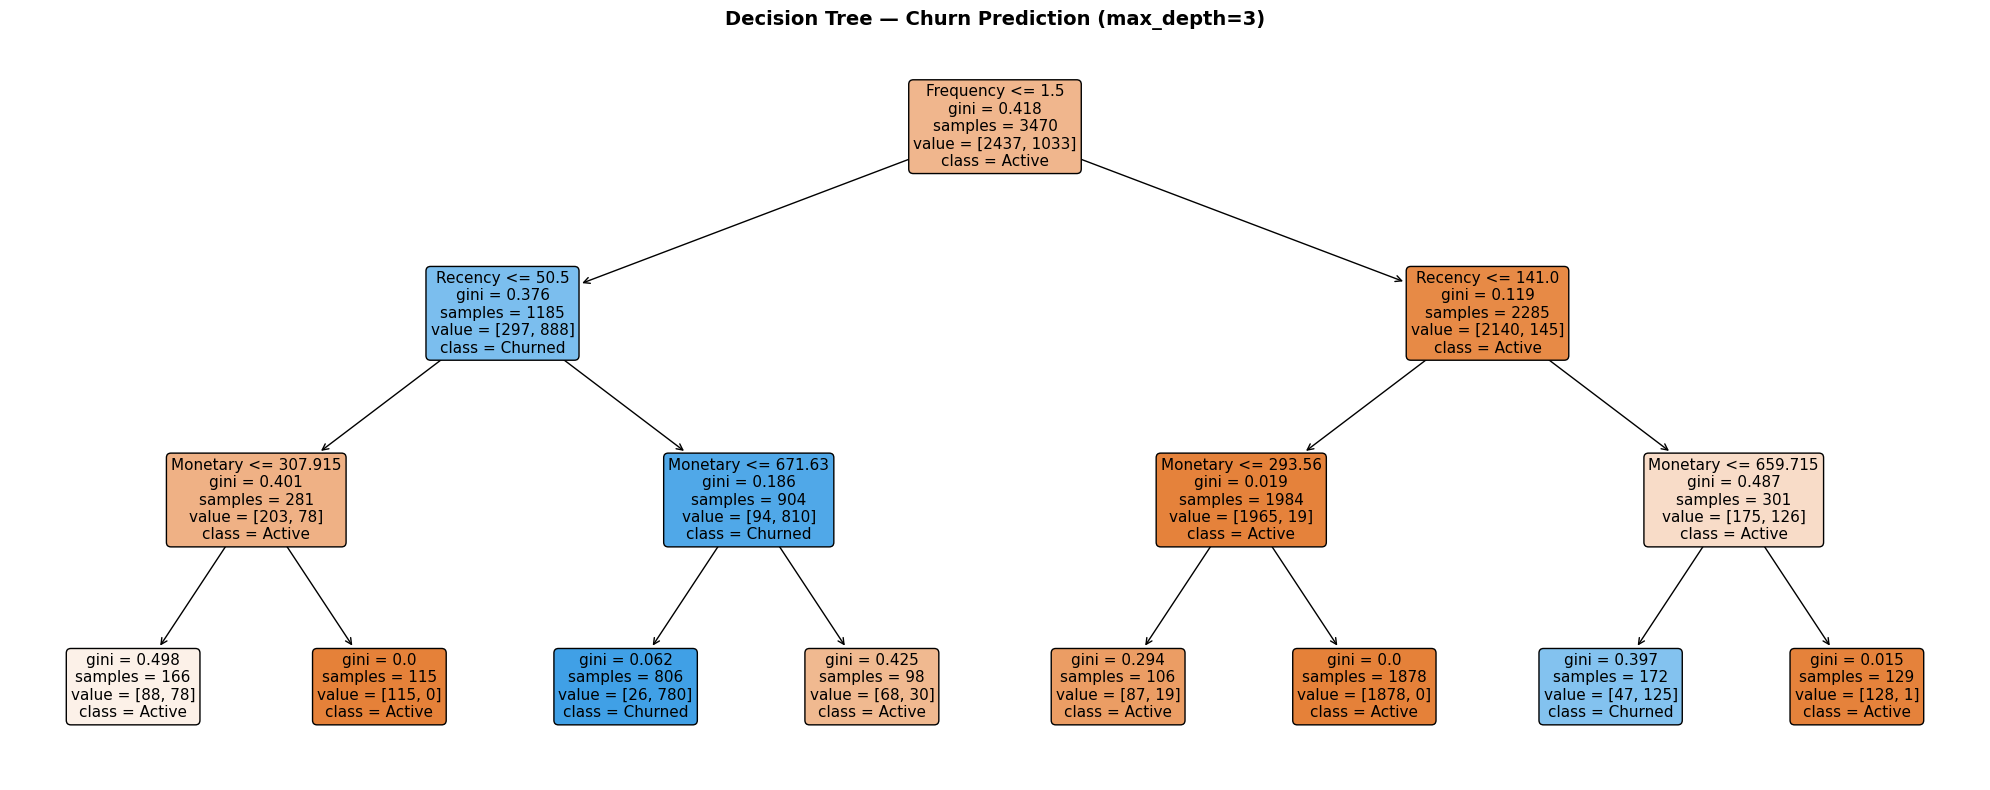

|--- Frequency <= 1.50
|   |--- Recency <= 50.50
|   |   |--- Monetary <= 307.91
|   |   |   |--- class: 0
|   |   |--- Monetary >  307.91
|   |   |   |--- class: 0
|   |--- Recency >  50.50
|   |   |--- Monetary <= 671.63
|   |   |   |--- class: 1
|   |   |--- Monetary >  671.63
|   |   |   |--- class: 0
|--- Frequency >  1.50
|   |--- Recency <= 141.00
|   |   |--- Monetary <= 293.56
|   |   |   |--- class: 0
|   |   |--- Monetary >  293.56
|   |   |   |--- class: 0
|   |--- Recency >  141.00
|   |   |--- Monetary <= 659.71
|   |   |   |--- class: 1
|   |   |--- Monetary >  659.71
|   |   |   |--- class: 0



In [3]:
# Train with limited depth first — easier to visualise
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Visualise
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt,
          feature_names=["Recency", "Frequency", "Monetary"],
          class_names=["Active", "Churned"],
          filled=True,
          rounded=True,
          fontsize=11,
          ax=ax)
plt.title("Decision Tree — Churn Prediction (max_depth=3)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/decision_tree.png", dpi=150)
plt.show()

# Text representation — good for understanding
print(export_text(dt, feature_names=["Recency", "Frequency", "Monetary"]))

**Evaluate**

In [4]:
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

      Active       0.94      0.97      0.95       610
     Churned       0.92      0.86      0.89       258

    accuracy                           0.93       868
   macro avg       0.93      0.91      0.92       868
weighted avg       0.93      0.93      0.93       868

ROC-AUC: 0.9824


**Why cross-validation matters**

In [5]:
# Problem with single train/test split:
# Results depend on which 20% ended up in test set — could be lucky or unlucky

# Cross-validation solution: split data K times, train/test on each split, average results

from sklearn.model_selection import cross_val_score, StratifiedKFold

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Test all 3 models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    "Decision Tree (depth=3)": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Logistic Regression":     LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest":           RandomForestClassifier(n_estimators=100, random_state=42),
}

print(f"{'Model':<30} {'Mean AUC':>10} {'Std AUC':>10} {'Min':>8} {'Max':>8}")
print("-" * 70)

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="roc_auc")
    print(f"{name:<30} {scores.mean():>10.4f} {scores.std():>10.4f} {scores.min():>8.4f} {scores.max():>8.4f}")

Model                            Mean AUC    Std AUC      Min      Max
----------------------------------------------------------------------
Decision Tree (depth=3)            0.9834     0.0030   0.9786   0.9868
Logistic Regression                0.9813     0.0034   0.9775   0.9865
Random Forest                      0.9945     0.0015   0.9931   0.9974


**Effect of tree depth on performance**

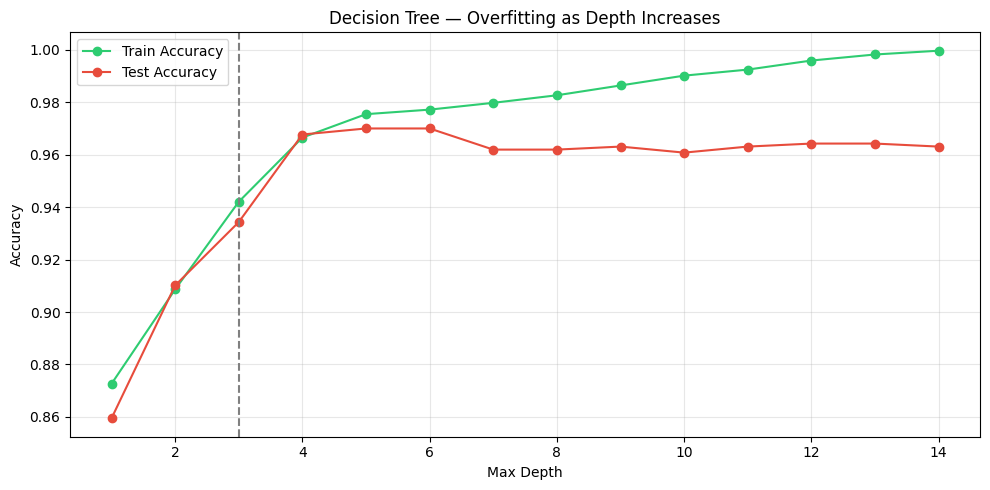

In [6]:
depths = range(1, 15)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, marker="o", label="Train Accuracy", color="#2ecc71")
plt.plot(depths, test_scores, marker="o", label="Test Accuracy", color="#e74c3c")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree — Overfitting as Depth Increases")
plt.legend()
plt.grid(alpha=0.3)
plt.axvline(x=3, color="gray", linestyle="--", label="Our choice (depth=3)")
plt.tight_layout()
plt.savefig("../output/tree_depth_overfitting.png", dpi=150)
plt.show()

**Find the best Decision Tree depth automatically**

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_scaled, y)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 224 candidates, totalling 1120 fits
Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best AUC: 0.9922


**Train final model with best params**

In [9]:
from sklearn.model_selection import GridSearchCV

# Use unscaled X for Decision Tree — trees don't need scaling
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_raw, y_train_raw)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

# Evaluate on held-out test set
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test_raw)
y_prob_best = best_dt.predict_proba(X_test_raw)[:, 1]

print("\nBest Decision Tree — Classification Report:")
print(classification_report(y_test_raw, y_pred_best, target_names=["Active", "Churned"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test_raw, y_prob_best):.4f}")

Fitting 5 folds for each of 224 candidates, totalling 1120 fits
Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV AUC: 0.9927

Best Decision Tree — Classification Report:
              precision    recall  f1-score   support

      Active       1.00      0.96      0.98       610
     Churned       0.91      0.99      0.95       258

    accuracy                           0.97       868
   macro avg       0.95      0.98      0.96       868
weighted avg       0.97      0.97      0.97       868

Test ROC-AUC: 0.9938
